# Imports

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import rasterio

from sklearn.metrics import confusion_matrix, classification_report

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Using device: cuda


# Config and Class Names

In [14]:
RGB_VAL  = "EuroSAT/val"
RGB_TEST = "EuroSAT_test_flat"

CLASSES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES  = 10

# Model architecture


In [15]:
from torchvision.models import densenet121

model = densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
model.load_state_dict(torch.load("best_densenet121.pth", map_location=device))
model = model.to(device)
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [16]:
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

# Validation dataset and loader

In [17]:
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class RGBDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for cls in CLASSES:
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(folder, fname), CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path

rgb_val_ds     = RGBDataset(RGB_VAL, val_transform)
rgb_val_loader = DataLoader(rgb_val_ds, batch_size=32, shuffle=False, num_workers=0)
print("Val samples:", len(rgb_val_ds))

Val samples: 4050


# Collecting all predictions and attention weights on val set

In [19]:
all_preds  = []
all_labels = []
all_paths  = []

with torch.no_grad():
    for x, y, paths in rgb_val_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y)
        all_paths.extend(paths)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Collected predictions for", len(all_preds), "samples")
print("Overall val accuracy:", (all_preds == all_labels).mean())

Collected predictions for 4050 samples
Overall val accuracy: 0.9814814814814815


# confusion matrix  (2C)

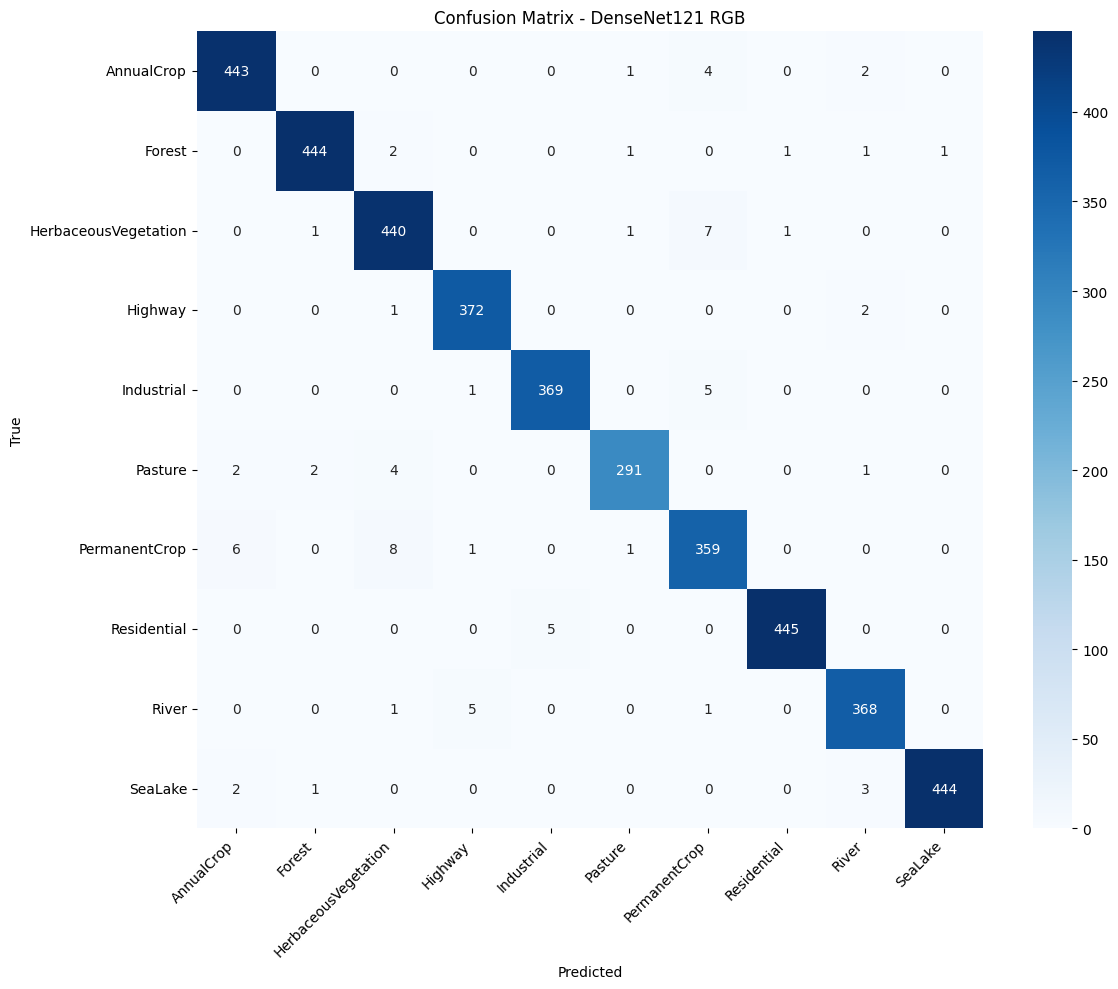

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       450
              Forest       0.99      0.99      0.99       450
HerbaceousVegetation       0.96      0.98      0.97       450
             Highway       0.98      0.99      0.99       375
          Industrial       0.99      0.98      0.99       375
             Pasture       0.99      0.97      0.98       300
       PermanentCrop       0.95      0.96      0.96       375
         Residential       1.00      0.99      0.99       450
               River       0.98      0.98      0.98       375
             SeaLake       1.00      0.99      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DenseNet121 RGB")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Most confused pair classes:  (2C)

In [21]:
# zero out diagonal (correct predictions) and find top confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# get top 5 confused pairs
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((cm_no_diag[i, j], CLASSES[i], CLASSES[j]))

confused_pairs.sort(reverse=True)
print("Top confused class pairs (true -> predicted):")
for count, true_cls, pred_cls in confused_pairs[:8]:
    print(f"  {true_cls} -> {pred_cls}: {count} samples")

Top confused class pairs (true -> predicted):
  PermanentCrop -> HerbaceousVegetation: 8 samples
  HerbaceousVegetation -> PermanentCrop: 7 samples
  PermanentCrop -> AnnualCrop: 6 samples
  River -> Highway: 5 samples
  Residential -> Industrial: 5 samples
  Industrial -> PermanentCrop: 5 samples
  Pasture -> HerbaceousVegetation: 4 samples
  AnnualCrop -> PermanentCrop: 4 samples


# Grad-CAM implementation (2A)
Grad-CAM hooks into the last conv layer and uses gradients to produce a spatial heatmap showing where the model focused.

In [23]:
class GradCAM:
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None

        # hook onto the last conv layer (index 12 in features = last Conv2d before classifier)
        target_layer = model.features.denseblock4.denselayer16.conv2
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        x = x.unsqueeze(0).to(device)  # add batch dim
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        self.model.zero_grad()
        out[0, class_idx].backward()

        # pool gradients over spatial dims
        weights     = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam         = (weights * self.activations).sum(dim=1).squeeze()  # (H, W)
        cam         = F.relu(cam)
        cam         = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), class_idx

gradcam = GradCAM(model)
print("GradCAM ready")

GradCAM ready


# Visualizing Grad-CAM on correct predictions (2A)
We pick one correct example per class and show the RGB view alongside the heatmap.

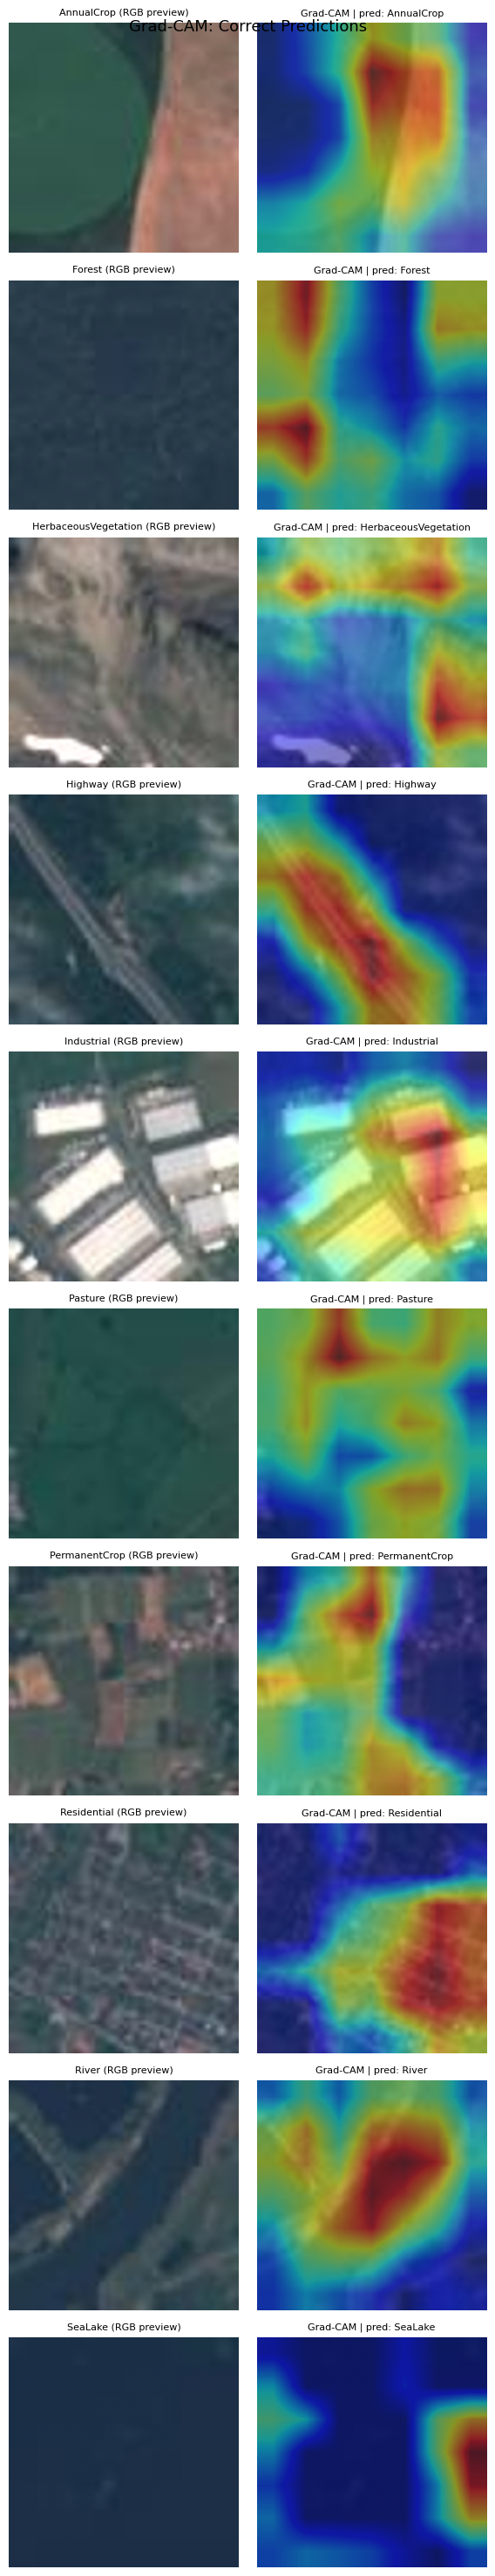

In [25]:
def load_rgb_preview(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((224, 224))
    return np.array(img) / 255.0

fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(6, NUM_CLASSES * 3))

for cls_idx, cls_name in enumerate(CLASSES):
    # find first correct prediction for this class
    mask    = (all_labels == cls_idx) & (all_preds == cls_idx)
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue
    sample_idx = indices[0]
    path       = all_paths[sample_idx]

    img = val_transform(Image.open(path).convert("RGB"))

    cam, pred_idx = gradcam.generate(img)
    rgb_preview   = load_rgb_preview(path)

    # upsample cam to 64x64
    cam_resized = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=(224, 224), mode="bilinear", align_corners=False
    ).squeeze().numpy()

    axes[cls_idx, 0].imshow(rgb_preview)
    axes[cls_idx, 0].set_title(f"{cls_name} (RGB preview)", fontsize=8)
    axes[cls_idx, 0].axis("off")

    axes[cls_idx, 1].imshow(rgb_preview)
    axes[cls_idx, 1].imshow(cam_resized, cmap="jet", alpha=0.5)
    axes[cls_idx, 1].set_title(f"Grad-CAM | pred: {CLASSES[pred_idx]}", fontsize=8)
    axes[cls_idx, 1].axis("off")

plt.suptitle("Grad-CAM: Correct Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("gradcam_correct.png", dpi=150)
plt.show()

# Grad-CAM on incorrect predictions (2A)
Same thing but for wrong predictions — picked the most confused pair from Cell 7.

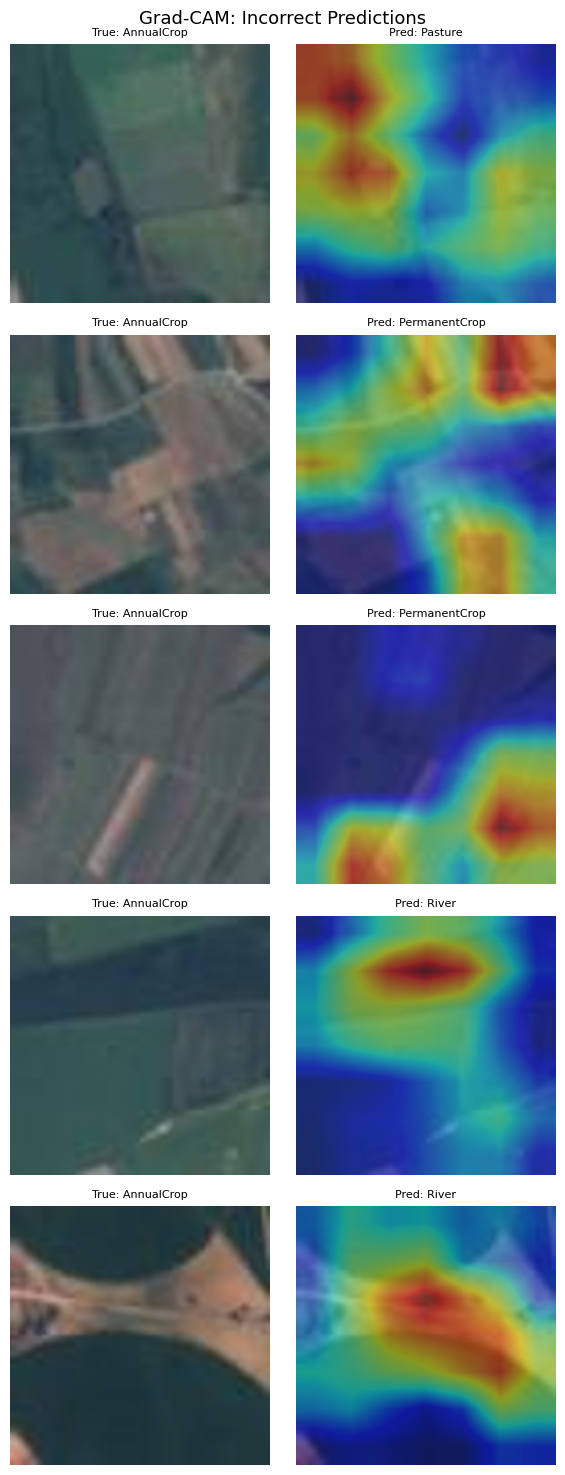

In [26]:
fig, axes = plt.subplots(5, 2, figsize=(6, 15))

# get 5 misclassified samples
wrong_indices = np.where(all_preds != all_labels)[0][:5]

for row, sample_idx in enumerate(wrong_indices):
    path      = all_paths[sample_idx]
    true_cls  = CLASSES[all_labels[sample_idx]]
    pred_cls  = CLASSES[all_preds[sample_idx]]

    img = val_transform(Image.open(path).convert("RGB"))

    cam, _ = gradcam.generate(img, class_idx=all_preds[sample_idx])
    cam_resized = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=(224, 224), mode="bilinear", align_corners=False
    ).squeeze().numpy()

    rgb_preview = load_rgb_preview(path)

    axes[row, 0].imshow(rgb_preview)
    axes[row, 0].set_title(f"True: {true_cls}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(rgb_preview)
    axes[row, 1].imshow(cam_resized, cmap="jet", alpha=0.5)
    axes[row, 1].set_title(f"Pred: {pred_cls}", fontsize=8)
    axes[row, 1].axis("off")

plt.suptitle("Grad-CAM: Incorrect Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("gradcam_incorrect.png", dpi=150)
plt.show()

# Generating MS test predictions CSV


In [27]:
class RGBTestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = [(os.path.join(root, f), f)
                        for f in os.listdir(root)
                        if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, fname = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, fname

rgb_test_ds     = RGBTestDataset(RGB_TEST, val_transform)
rgb_test_loader = DataLoader(rgb_test_ds, batch_size=32, shuffle=False, num_workers=0)
print("Test samples:", len(rgb_test_ds))

Test samples: 4050


In [28]:
img_ids, pred_labels = [], []

model.eval()
with torch.no_grad():
    for x, fnames in rgb_test_loader:
        x    = x.to(device)
        out  = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        for fname, pred in zip(fnames, preds):
            img_ids.append(fname)
            pred_labels.append(pred)

rgb_df  = pd.DataFrame({"img_id": img_ids, "predicted_label": pred_labels})
rgb_df .to_csv("ms_predictions.csv", index=False)
print("Saved ms_predictions.csv")
print(rgb_df .head(10))
print("Label distribution:")
print(rgb_df ["predicted_label"].value_counts().sort_index())

Saved ms_predictions.csv
          img_id  predicted_label
0     test_1.jpg                0
1    test_10.jpg                0
2   test_100.jpg                0
3  test_1000.jpg                2
4  test_1001.jpg                2
5  test_1002.jpg                2
6  test_1003.jpg                2
7  test_1004.jpg                1
8  test_1005.jpg                2
9  test_1006.jpg                2
Label distribution:
predicted_label
0    457
1    447
2    442
3    373
4    376
5    304
6    377
7    451
8    374
9    449
Name: count, dtype: int64
